# EDA

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv("/kaggle/input/titanic/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df = df.drop(['PassengerId','Name','Ticket','Cabin'] , axis='columns')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [5]:
df.dropna(subset=['Embarked'], inplace=True)

Text(0, 0.5, 'Frequency')

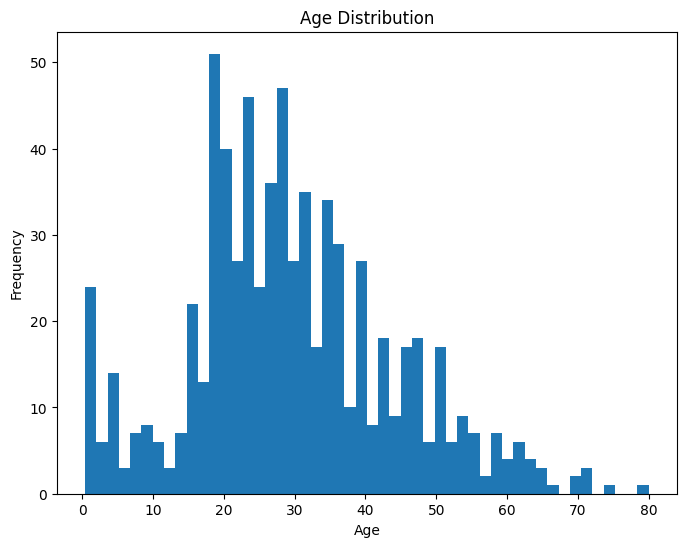

In [6]:
plt.figure(figsize=(8,6))
plt.hist(df['Age'], bins = 50)
plt.title("Age Distribution")
plt.xlabel('Age')
plt.ylabel('Frequency')

<Axes: xlabel='Fare', ylabel='Count'>

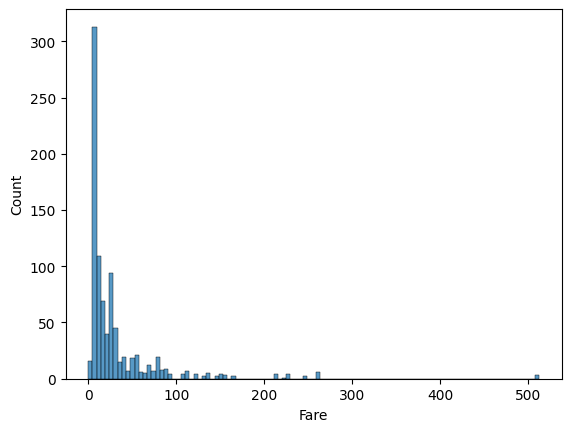

In [7]:
sns.histplot(data=df, x="Fare")

# Data preprocessing

In [8]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

In [9]:
#Encoding categorical values
encoder = LabelEncoder()
df['Sex'] = encoder.fit_transform(df['Sex'])
df['Embarked'] = encoder.fit_transform(df['Embarked'])

In [10]:
scaler = MinMaxScaler()
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])

# Replace NaN values in Age

In [11]:
columns = df.columns
columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

In [12]:
from sklearn.impute import KNNImputer

In [13]:
imputer = KNNImputer(n_neighbors=5)
df = imputer.fit_transform(df)

In [14]:
df = pd.DataFrame(df, columns= columns)

Text(0, 0.5, 'Frequency')

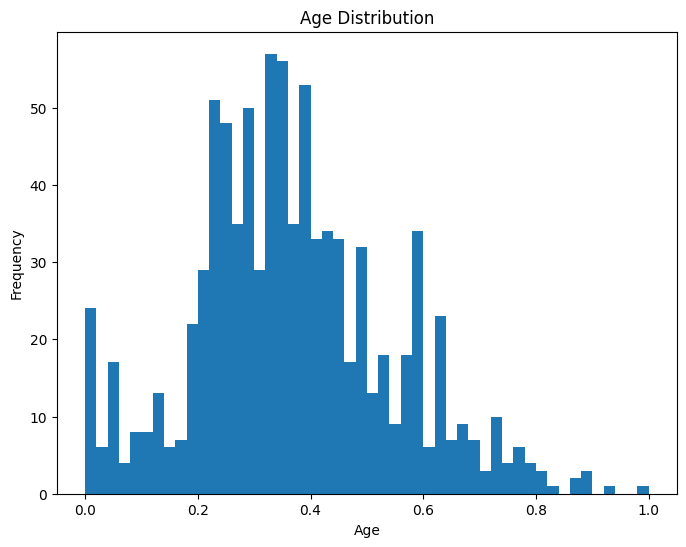

In [15]:
plt.figure(figsize=(8,6))
plt.hist(df['Age'], bins = 50)
plt.title("Age Distribution")
plt.xlabel('Age')
plt.ylabel('Frequency')

# ML Models

In [16]:
X = df.iloc[ : , 1:]
y = df.iloc[ : , 0]

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)

# LogisticRegression

In [19]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
acc_log = round(logreg.score(X_train, y_train) * 100, 3)
log = round(logreg.score(X_test, y_test) * 100, 3)
print("Train: ", acc_log)
print("Test: ", log)

Train:  81.435
Test:  83.146


# RandomForestClassifier

In [20]:
RandomForestClassifier = RandomForestClassifier(
    max_features=.7,
    min_samples_leaf=10,
    min_samples_split=8,
    n_estimators=10,
    max_depth=15,
    verbose=1)
RandomForestClassifier.fit(X_train, y_train)
acc_random_forest = round(RandomForestClassifier.score(X_train, y_train) * 100, 3) 
random_forest = round(RandomForestClassifier.score(X_test, y_test) * 100, 3) 
print("Train: ", acc_random_forest)
print("Test: ", random_forest)

Train:  84.951
Test:  85.393


# GradientBoostingClassifier

In [21]:
GradientBoostingClassifier = GradientBoostingClassifier(
    learning_rate=0.01,
    max_depth=10,
    max_features=0.8,
    min_samples_leaf=2,
    min_samples_split=2,
    n_estimators=100,
    subsample=0.4,
    random_state=42
)
GradientBoostingClassifier.fit(X_train, y_train)
acc_GBC = round(GradientBoostingClassifier.score(X_train, y_train) * 100, 3)
GBC = round(GradientBoostingClassifier.score(X_test, y_test) * 100, 3)
print("Train: ", acc_GBC)
print("Test: ", GBC)

Train:  90.577
Test:  87.079


# ExtraTreesClassifier

In [22]:
ExtraTreesClassifier = ExtraTreesClassifier(
    bootstrap=True,
    criterion='gini',
    max_features=0.65,
    min_samples_leaf=1,
    min_samples_split=6,
    n_estimators=100,
    random_state=42
)
ExtraTreesClassifier.fit(X_train, y_train)
acc_extra_tree = round(ExtraTreesClassifier.score(X_train, y_train) * 100, 3)
extra_tree = round(ExtraTreesClassifier.score(X_test, y_test) * 100, 3)
print("Train: ", acc_extra_tree)
print("Test: ", extra_tree)

Train:  90.999
Test:  87.079


## Confusion matrix to show how many times the model went wrong.

Text(70.72222222222221, 0.5, 'Truth')

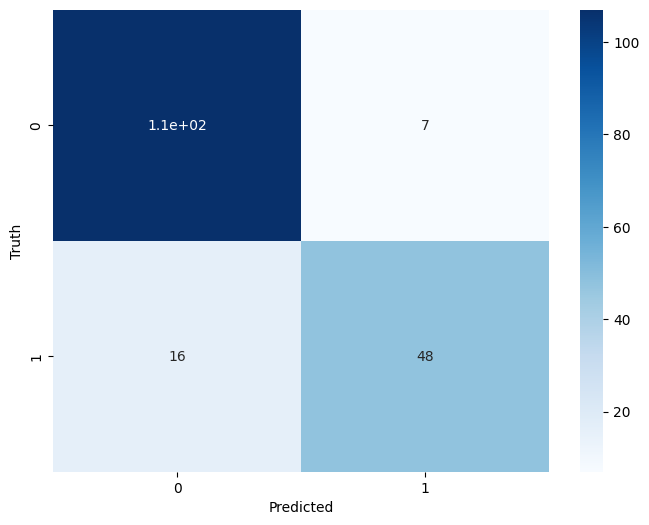

In [23]:
y_predicted = ExtraTreesClassifier.predict(X_test)
cm = confusion_matrix(y_test, y_predicted)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True,cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [24]:
models = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest',
              'ExtraTreesClassifier','GradientBoostingClassifier'],
    
    'Training_score': [acc_log, acc_random_forest,
                       acc_extra_tree,acc_GBC],
    
    'Testing_score' : [log, random_forest,
                       extra_tree,GBC]})

models.sort_values(by='Testing_score', ascending=False)

,Model,Training_score,Testing_score
2,ExtraTreesClassifier,90.999,87.079
3,GradientBoostingClassifier,90.577,87.079
1,Random Forest,84.951,85.393
0,Logistic Regression,81.435,83.146


# Submission

In [25]:
test_data = pd.read_csv("/kaggle/input/titanic/test.csv")
test = test_data.drop(['PassengerId','Name','Ticket','Cabin'] , axis='columns')
test['Sex'] = encoder.fit_transform(test['Sex'])
test['Embarked'] = encoder.fit_transform(test['Embarked'])
imputer = KNNImputer(n_neighbors=2)
test = imputer.fit_transform(test)
test = pd.DataFrame(test, columns=columns[1:])
predictions = RandomForestClassifier.predict(test)
predictions = predictions.astype(int)

In [26]:
output = pd.DataFrame({'PassengerId': test_data.PassengerId, 'Survived': predictions})
output.to_csv('/kaggle/working/submission.csv', index=False)

# Save the model

In [27]:
import pickle

In [28]:
with open('Titanic_model','wb') as file:
    pickle.dump(GradientBoostingClassifier,file)